# Large-scale DFT-D4: liquid ethanol from rMD17 conformers, up to the memory limit

The D4 dispersion correction has two costs that grow faster than the short-range
model's: the electronegativity-equilibration (EEQ) charges, a charge-constrained
linear system of size $N$, and the three-body (ATM) term, a sum over all atom
triples within its cutoff. xnn evaluates both in two *regimes* of one `DFTD4`
class: `dense` (bit-exact against the reference `dftd4`, memory $\propto N^2$) and
`large` (a matrix-free Ewald operator with implicit differentiation for the EEQ
charges, recompute blocks for the triples and the pair term, memory linear in the
number of atoms).

This notebook pushes the large regime as far as one 80 GB GPU allows:

1. train a small MACE on rMD17 ethanol (energies and forces of single molecules);
2. pack rMD17 conformers into periodic **liquid-ethanol boxes** at the experimental
   density, from 576 to 72 000 atoms;
3. evaluate MACE + D4 (energy, forces, stress) on every box: time and peak memory
   vs. size, the dense regime alongside where it still fits, up to the box where
   the corrected model no longer fits in memory;
4. the cost of a **training step** (force loss, double backward) on the largest
   box that fits, the per-rank cost of a DDP run;
5. the EEQ solvers (LU vs. conjugate gradients) at 9 000 and 20 000 atoms;
6. a short NVE run on a 4 608-atom box through the ASE calculator.

The neighbor list uses `vesin` on the GPU (`pip install vesin-torch`); without it
the brute-force reference list dominates memory above a few thousand atoms.


In [1]:
import logging, math, os, time, warnings
from pathlib import Path
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt
from ase import Atoms, units
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.verlet import VelocityVerlet

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

from xnn.common.config import from_dict
from xnn.common.data import AtomicDataset, collate, load_dataset, structure_to_graph
from xnn.common.data import neighborlist
from xnn.common.deploy import XNNCalculator
from xnn.common.models import D4Dispersion, ForceStressOutput, build_model
from xnn.common.models import eeq
from xnn.common.models.d4 import BOHR

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu",
      "| vesin cell list:", neighborlist._HAS_VESIN, "| float64")


def is_oom(err):
    # a CUDA OOM raised inside a TorchScript-compiled block (e3nn in MACE) arrives as a RuntimeError
    return isinstance(err, torch.OutOfMemoryError) or "out of memory" in str(err)


def release():
    import gc
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


def peak_run(fn, sync=True):
    # wall time and peak device memory of one call
    if DEVICE == "cuda":
        torch.cuda.synchronize(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    t = time.perf_counter()
    out = fn()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    dt = time.perf_counter() - t
    peak = torch.cuda.max_memory_allocated() / 1e9 if DEVICE == "cuda" else float("nan")
    return out, dt, peak


device: NVIDIA A100 80GB PCIe | vesin cell list: True | float64


## 1. A short-range model: MACE on rMD17 ethanol

rMD17 (Christensen & von Lilienfeld, 2020) provides 100 000 PBE/def2-SVP
conformers of ethanol. We train a small MACE on 900 of them (100 for validation,
200 held out) with a 5 Å cutoff, a couple of minutes on the GPU. The checkpoint is
reused on later runs.


In [2]:
CUTOFF = 5.0
SPECIES = [1, 6, 8]
splits = load_dataset("rmd17", molecule="ethanol", n_train=1000, n_test=200, cutoff=None)
train_structs, test_structs = splits["train"], splits["test"]
n_atoms_mol = len(train_structs[0]["atomic_numbers"])
# a single composition cannot separate per-element reference energies: spread the mean
E0 = {z: float(np.mean([s["energy"] for s in train_structs])) / n_atoms_mol for z in SPECIES}

probe = AtomicDataset(train_structs[:20], CUTOFF)
LAMBDA = float(sum(probe[i].num_edges for i in range(len(probe))) / sum(probe[i].num_nodes for i in range(len(probe))))

cfg = from_dict({
    "model": {"name": "mace", "cutoff": CUTOFF, "n_features": 32, "n_interactions": 2,
              "n_rbf": 8, "species": SPECIES, "max_ell": 3, "max_L": 1, "correlation": 3,
              "hidden_irreps": "32x0e+32x1o", "MLP_irreps": "16x0e",
              "avg_num_neighbors": LAMBDA, "atomic_energies": [E0[z] for z in SPECIES]},
    "data": {"batch_size": 32},
    "optim": {"lr": 0.01, "weight_decay": 5e-7, "epochs": 40,
              "energy_weight": 1.0, "force_weight": 100.0, "scheduler": "plateau"},
    "device": DEVICE, "seed": 0, "output_dir": "runs/d4_large_ethanol",
})
ckpt = Path(cfg.output_dir) / "best.pt"
if not ckpt.exists():
    from xnn.common.train import Trainer
    rng = np.random.default_rng(0)
    idx = rng.permutation(len(train_structs))
    t0 = time.time()
    Trainer(cfg, AtomicDataset([train_structs[i] for i in idx[100:]], CUTOFF),
            AtomicDataset([train_structs[i] for i in idx[:100]], CUTOFF)).fit()
    print(f"trained {cfg.optim.epochs} epochs in {time.time() - t0:.0f} s")
state = torch.load(ckpt, map_location="cpu", weights_only=False)
mace = build_model(state["cfg"].model)
ForceStressOutput(mace).load_state_dict(state["model"])
mace = mace.to(DEVICE).eval()

# held-out accuracy
test_ds = AtomicDataset(test_structs, CUTOFF)
batch = collate([test_ds[i] for i in range(len(test_ds))]).to(DEVICE)
out = ForceStressOutput(mace)(batch)
e_err = (out["energy"].detach().cpu() - batch.energy.cpu()) / n_atoms_mol
f_err = out["forces"].detach().cpu() - batch.forces.cpu()
print(f"rMD17 ethanol, 200 held-out conformers: energy MAE {1e3 * e_err.abs().mean():.2f} meV/atom, "
      f"force RMSE {1e3 * f_err.pow(2).mean().sqrt():.1f} meV/Å")


rmd17:ethanol train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/200 [00:00<?, ? struct/s]

rMD17 ethanol, 200 held-out conformers: energy MAE 2.26 meV/atom, force RMSE 38.4 meV/Å


## 2. Liquid-ethanol boxes from rMD17 conformers

Held-out conformers are placed on a jittered cubic lattice whose spacing gives the
experimental liquid density (0.789 g/cm³, 96.9 Å³ per molecule), each with the
random orientation, out of 30 trials, that keeps it farthest from the atoms already
placed. This is not an equilibrated liquid, but it has the right density, the right
neighbor counts and no unphysical contacts, which is what the cost of D4 depends on.


In [3]:
V_MOL = 46.069 / (0.789 * 0.6022140)          # Å^3 per ethanol molecule at 0.789 g/cm^3
A_LAT = V_MOL ** (1.0 / 3.0)                   # lattice spacing, 4.59 Å
CONFS = [s["pos"] - s["pos"].mean(0) for s in test_structs]
Z_MOL = np.asarray(test_structs[0]["atomic_numbers"])


def random_rotations(n, rng):
    q = rng.normal(size=(n, 4)); q /= np.linalg.norm(q, axis=1, keepdims=True)
    w, x, y, z = q.T
    return np.stack([
        np.stack([1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w)], -1),
        np.stack([2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w)], -1),
        np.stack([2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y)], -1)], 1)


def pack_ethanol(n_side, seed=0, trials=30, jitter=0.3):
    rng = np.random.default_rng(seed)
    L = n_side * A_LAT
    grid = {}                                   # lattice site -> atom positions placed there
    pos_all, dmin_all = [], []
    for site in np.ndindex(n_side, n_side, n_side):
        center = (np.array(site) + 0.5) * A_LAT + rng.uniform(-jitter, jitter, 3)
        conf = CONFS[rng.integers(len(CONFS))]
        cands = np.einsum("tij,aj->tai", random_rotations(trials, rng), conf) + center   # (T, 9, 3)
        near = []
        for d in np.ndindex(3, 3, 3):
            nb = tuple((np.array(site) + np.array(d) - 1) % n_side)
            if nb in grid:
                shift = ((np.array(site) + np.array(d) - 1) // n_side) * L
                near.append(grid[nb] + shift)
        if near:
            near = np.concatenate(near)
            dist = np.linalg.norm(cands[:, :, None, :] - near[None, None, :, :], axis=-1).min(axis=(1, 2))
            best = int(dist.argmax()); dmin_all.append(float(dist[best]))
        else:
            best = 0
        grid[site] = cands[best]
        pos_all.append(cands[best])
    pos = np.concatenate(pos_all)
    atoms = Atoms(numbers=np.tile(Z_MOL, n_side ** 3), positions=pos, cell=np.eye(3) * L, pbc=True)
    atoms.wrap()
    return atoms, min(dmin_all)


t = time.perf_counter()
box, dmin = pack_ethanol(8)
print(f"8^3 = 512 molecules, {len(box)} atoms, box {box.cell[0, 0]:.1f} Å, "
      f"closest intermolecular contact {dmin:.2f} Å, packed in {time.perf_counter() - t:.1f} s")


8^3 = 512 molecules, 4608 atoms, box 36.8 Å, closest intermolecular contact 1.61 Å, packed in 0.7 s


## 3. MACE + D4 across sizes: time, memory and the dense/large agreement

Production cutoffs: 12 Å for the pair term (with a 2 Å switching window), 8 Å for
the triples and the coordination numbers. The three-body sum then holds about
$2\times10^4$ triples per atom; the EEQ real-space range is the 12 Å pair cutoff
(22.7 bohr), which sets the Ewald split.

The first box is evaluated twice (the first call compiles the cell-list kernels and
warms the allocator); every later box once. The dense regime runs alongside while
its $(N,N)$ Wigner-Seitz image search fits. The ladder stops at the first box the
corrected model cannot evaluate on this GPU.


In [4]:
D4_OPTS = dict(cutoff_pair=12.0, cutoff_triple=8.0, cutoff_cn=8.0, cutoff_eeq_cn=8.0,
               switch_width_pair=2.0, switch_width_triple=1.0)
SIZES = (4, 6, 8, 10, 12, 13, 14, 16)      # molecules per box edge: 576 ... 36 864 atoms


def corrected(regime, **extra):
    m = D4Dispersion(mace, regime=regime, **D4_OPTS, **extra)
    return ForceStressOutput(m, compute_stress=True).to(DEVICE).eval()


def graph_of(atoms, cutoff):
    s = {"pos": torch.tensor(atoms.positions, device=DEVICE),
         "atomic_numbers": torch.tensor(atoms.numbers, device=DEVICE),
         "cell": torch.tensor(atoms.cell.array, device=DEVICE),
         "pbc": torch.tensor([True, True, True], device=DEVICE)}
    return structure_to_graph(s, cutoff, device=DEVICE)


large = corrected("large")
dense = corrected("dense")
rows = []
for n_side in SIZES:
    atoms, dmin = pack_ethanol(n_side)
    n = len(atoms)
    row = {"n_side": n_side, "atoms": n, "dmin": dmin, "t_mace": float("nan"), "m_mace": float("nan")}
    graph, t_graph, _ = peak_run(lambda: graph_of(atoms, large.cutoff))
    row["edges"] = int(graph.edge_index.shape[1]); row["t_graph"] = t_graph
    del graph
    try:
        if not rows:
            peak_run(lambda: large(graph_of(atoms, large.cutoff)))            # warm-up once
        out, t, m = peak_run(lambda: large(graph_of(atoms, large.cutoff)))
        row.update(t_mace=t, m_mace=m, e_atom=float(out["energy"]) / n, e_disp=float(out["energy_disp"]) / n,
                   p_gpa=float(-out["stress"][0].diagonal().mean()) / units.GPa)
        f_large = out["forces"].detach(); del out
    except Exception as err:
        if not is_oom(err):
            raise
        print(f"{n_side}^3 mol, {n} atoms, {row['edges'] / 1e6:.1f} M edges: MACE + D4 out of memory "
              f"(peak {torch.cuda.max_memory_allocated() / 1e9:.0f} GB)")
        release(); rows.append(row)
        break
    if n <= 2500:                                   # the dense regime, while its (N, N) image search fits
        try:
            outd, t, m = peak_run(lambda: dense(graph_of(atoms, dense.cutoff)))
            row.update(t_dense=t, m_dense=m, de=abs(float(outd["energy"]) - row["e_atom"] * n),
                       df=float((outd["forces"] - f_large).abs().max()))
            del outd
        except Exception as err:
            if not is_oom(err):
                raise
            release()
    rows.append(row)
    print(f"{n_side:2d}^3 mol, {n:6d} atoms, {row['edges'] / 1e6:6.1f} M edges | MACE+D4 large: "
          f"{row['t_mace']:6.1f} s, {row['m_mace']:5.1f} GB"
          + (f" | dense: {row['t_dense']:6.1f} s, {row['m_dense']:5.1f} GB, dE {row['de']:.1e} eV, dF {row['df']:.1e} eV/Å"
             if "t_dense" in row else "")
          + f" | E_disp {row['e_disp'] * 1e3:7.2f} meV/atom, P {row['p_gpa']:.2f} GPa")
    release()


 4^3 mol,    576 atoms,    0.4 M edges | MACE+D4 large:    2.6 s,   5.7 GB | dense:    0.6 s,   7.0 GB, dE 2.2e-05 eV, dF 1.5e-06 eV/Å | E_disp  -29.65 meV/atom, P -0.90 GPa


 6^3 mol,   1944 atoms,    1.3 M edges | MACE+D4 large:    1.8 s,   7.0 GB | dense:    4.9 s,  69.4 GB, dE 4.9e-08 eV, dF 3.2e-09 eV/Å | E_disp  -29.64 meV/atom, P -0.66 GPa


 8^3 mol,   4608 atoms,    3.1 M edges | MACE+D4 large:    4.6 s,  22.1 GB | E_disp  -29.65 meV/atom, P -0.78 GPa


10^3 mol,   9000 atoms,    6.1 M edges | MACE+D4 large:   12.5 s,  30.3 GB | E_disp  -29.63 meV/atom, P -0.70 GPa


12^3 mol,  15552 atoms,   10.5 M edges | MACE+D4 large:   61.2 s,  51.2 GB | E_disp  -29.65 meV/atom, P -0.66 GPa


13^3 mol,  19773 atoms,   13.4 M edges | MACE+D4 large:  100.8 s,  65.1 GB | E_disp  -29.64 meV/atom, P -0.68 GPa


14^3 mol, 24696 atoms, 16.7 M edges: MACE + D4 out of memory (peak 78 GB)


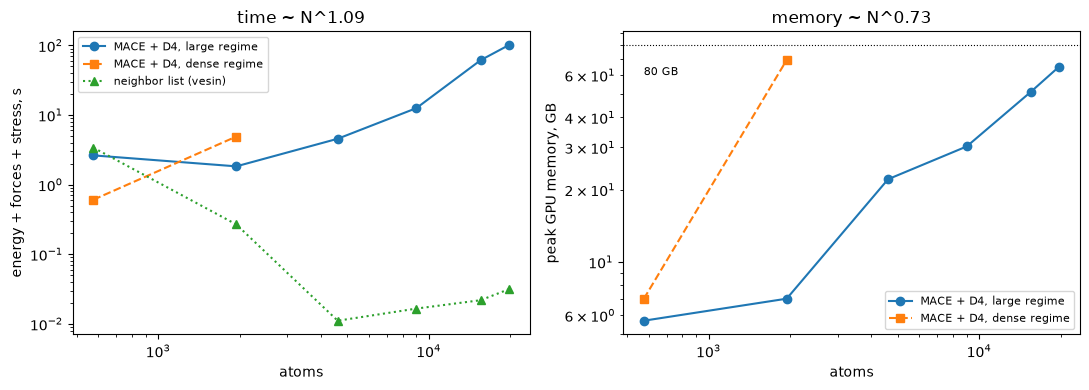

largest box evaluated: 19773 atoms in 100.8 s and 65.1 GB; the next box (24696 atoms) ran out of memory


In [5]:
ok = [r for r in rows if not math.isnan(r["t_mace"])]
ok_dense = [r for r in rows if "t_dense" in r and not math.isnan(r["t_dense"])]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
N = np.array([r["atoms"] for r in ok])
ax[0].loglog(N, [r["t_mace"] for r in ok], "o-", label="MACE + D4, large regime")
ax[0].loglog([r["atoms"] for r in ok_dense], [r["t_dense"] for r in ok_dense], "s--", label="MACE + D4, dense regime")
ax[0].loglog(N, [r["t_graph"] for r in ok], "^:", label="neighbor list (vesin)")
ax[0].set_xlabel("atoms"); ax[0].set_ylabel("energy + forces + stress, s"); ax[0].legend(fontsize=8)
ax[1].loglog(N, [r["m_mace"] for r in ok], "o-", label="MACE + D4, large regime")
ax[1].loglog([r["atoms"] for r in ok_dense], [r["m_dense"] for r in ok_dense], "s--", label="MACE + D4, dense regime")
ax[1].axhline(80, color="k", lw=0.8, ls=":"); ax[1].text(N[0], 60, "80 GB", fontsize=8)
ax[1].set_xlabel("atoms"); ax[1].set_ylabel("peak GPU memory, GB"); ax[1].legend(fontsize=8)
p_t = np.polyfit(np.log(N), np.log([r["t_mace"] for r in ok]), 1)[0]
p_m = np.polyfit(np.log(N), np.log([r["m_mace"] for r in ok]), 1)[0]
ax[0].set_title(f"time ~ N^{p_t:.2f}"); ax[1].set_title(f"memory ~ N^{p_m:.2f}")
plt.tight_layout(); plt.show()
print(f"largest box evaluated: {ok[-1]['atoms']} atoms in {ok[-1]['t_mace']:.1f} s and {ok[-1]['m_mace']:.1f} GB"
      + (f"; the next box ({rows[-1]['atoms']} atoms) ran out of memory" if math.isnan(rows[-1]["t_mace"]) else ""))


The dense regime reproduces the reference code and agrees with the large one to its
own Ewald tolerance ($\sim 10^{-8}$ in the charges, see the `dE`, `dF` columns), but
its Wigner-Seitz image search stores about 7 kB per atom pair and drops out after
the second box. In the large regime the peak is set by edge-sized tensors: the
MACE's per-edge equivariant features within its 5 Å cutoff and the D4 two-body
term's $(E, 23)$ polarizability arrays over the 12 Å neighbor list. The triples
and the EEQ charges, the two terms the large regime was built for, no longer
appear in the peak.


## 4. A training step on the largest box: the per-rank cost of DDP

Force training differentiates the forces once more (`create_graph=True`). With plain
gradient checkpointing that second backward would retain every three-body block again;
xnn's recompute blocks re-derive the block gradient instead, so a training step costs
about 2.5 times an evaluation at the same memory. This is what each rank of a DDP run
pays per structure of this size.


In [6]:
train_row = None
for r in reversed(ok):
    atoms, _ = pack_ethanol(r["n_side"])
    model = corrected("large", trainable=True)
    model.train()
    graph = graph_of(atoms, model.cutoff)
    f_ref = torch.zeros(len(atoms), 3, device=DEVICE)

    def step():
        out = model(graph)
        loss = ((out["forces"] - f_ref) ** 2).mean() + (out["energy"] / len(atoms)) ** 2
        loss.backward()
        return float(loss)

    try:
        _, t_train, m_train = peak_run(step)
        train_row = (r["atoms"], t_train, m_train, r["t_mace"], r["m_mace"])
        print(f"{r['atoms']} atoms: training step {t_train:.1f} s, peak {m_train:.1f} GB "
              f"(evaluation: {r['t_mace']:.1f} s, {r['m_mace']:.1f} GB)")
        break
    except Exception as err:
        if not is_oom(err):
            raise
        print(f"{r['atoms']} atoms: training step out of memory, trying the next smaller box")
    finally:
        model.eval(); model.zero_grad(set_to_none=True); release()


19773 atoms: training step out of memory, trying the next smaller box


15552 atoms: training step out of memory, trying the next smaller box


9000 atoms: training step 30.1 s, peak 58.4 GB (evaluation: 12.5 s, 30.3 GB)


## 5. The EEQ solvers

Below 12 000 atoms the assembled operator is LU-factorized (two $(N,N)$ tensors, no
autograd graph); above, Jacobi-preconditioned conjugate gradients on the matrix-free
operator, with the charge constraint eliminated. The Ewald split follows from the
real-space range: $\alpha = \mathrm{erfc}^{-1}(10^{-10}) / r_c$, and the reciprocal set
grows with the cell volume.


In [7]:
for n_side in (10, 13):
    atoms, _ = pack_ethanol(n_side)
    n = len(atoms)
    alpha = eeq.ewald_alpha(D4_OPTS["cutoff_pair"] / BOHR)
    grid, gvec, gfac = eeq.reciprocal_vectors(torch.tensor(atoms.cell.array) / BOHR, alpha)
    print(f"{n} atoms: alpha = {alpha:.4f} bohr^-1, {gvec.shape[0]} reciprocal vectors, "
          f"N x N_G = {n * gvec.shape[0] / 1e6:.0f} M entries")
    for solver in ("lu", "cg"):
        m = corrected("large", eeq_solver=solver)
        peak_run(lambda: m(graph_of(atoms, m.cutoff)))
        out, dt, mem = peak_run(lambda: m(graph_of(atoms, m.cutoff)))
        q = out["eeq_charges"].detach()
        print(f"    {solver.upper():3s}: {dt:6.2f} s, {mem:5.1f} GB (MACE + D4), sum q = {float(q.sum()):+.1e}, "
              f"q range [{float(q.min()):+.3f}, {float(q.max()):+.3f}] e")
        del out, m; release()


9000 atoms: alpha = 0.2017 bohr^-1, 80268 reciprocal vectors, N x N_G = 722 M entries


    LU :  10.43 s,  30.5 GB (MACE + D4), sum q = +2.8e-15, q range [-0.572, +0.305] e


    CG :  22.18 s,  29.9 GB (MACE + D4), sum q = -5.6e-16, q range [-0.572, +0.305] e


19773 atoms: alpha = 0.2017 bohr^-1, 175828 reciprocal vectors, N x N_G = 3477 M entries


    LU :  38.23 s,  68.5 GB (MACE + D4), sum q = -4.4e-16, q range [-0.581, +0.327] e


    CG : 100.96 s,  65.4 GB (MACE + D4), sum q = +4.4e-16, q range [-0.581, +0.327] e


With a 12 Å real-space range the splitting parameter is fixed at $\alpha = 0.20$ bohr$^{-1}$
and the reciprocal set grows with the cell volume: 80 000 vectors at 9 000 atoms, 176 000 at
19 773. The structure-factor table $N \times N_G$ then exceeds the in-memory budget and the
reciprocal sum is recomputed in chunks of $\mathbf{G}$ vectors at every operator application,
which is why conjugate gradients (tens of applications) cost more than the one-time assembly
and LU factorization here, even though `eeq_solver: auto` switches to CG above 12 000 atoms
to bound memory. On a GPU with room for two $(N, N)$ tensors, `eeq_solver: lu` is the faster
choice at this size; a longer `cutoff_eeq` (with the wider neighbor list it implies) shrinks
the reciprocal set as $r_c^{-3}$, and particle-mesh Ewald is the scalable replacement.

## 6. NVE dynamics on a 4 608-atom box

The ASE calculator rebuilds the neighbor list every step (vesin on the GPU, tens of
milliseconds) and evaluates MACE + D4 in the large regime. Twenty steps of velocity
Verlet at 0.5 fs from a Maxwell-Boltzmann draw at 300 K: the step time is what an
MD run of this size would pay per step, and the drift of the total energy checks
that the forces are the gradient of the energy through the implicit EEQ derivative.


In [8]:
atoms, _ = pack_ethanol(8)
md_model = corrected("large")
atoms.calc = XNNCalculator(md_model, cutoff=md_model.cutoff, device=DEVICE)
MaxwellBoltzmannDistribution(atoms, temperature_K=300, rng=np.random.default_rng(0))
dyn = VelocityVerlet(atoms, timestep=0.5 * units.fs)
e_tot = []
atoms.get_potential_energy()                       # warm-up
t0 = time.perf_counter()
for _ in range(20):
    dyn.run(1)
    e_tot.append(atoms.get_potential_energy() + atoms.get_kinetic_energy())
dt = (time.perf_counter() - t0) / 20
e_tot = np.array(e_tot)
print(f"{len(atoms)} atoms: {dt * 1e3:.0f} ms per MD step, T = {atoms.get_temperature():.0f} K, "
      f"total-energy drift {1e3 * (e_tot[-1] - e_tot[0]) / len(atoms):+.3f} meV/atom over 10 fs "
      f"(fluctuation {1e3 * e_tot.std() / len(atoms):.3f} meV/atom)")


4608 atoms: 4525 ms per MD step, T = 488 K, total-energy drift -0.119 meV/atom over 10 fs (fluctuation 0.052 meV/atom)


The packed box is not an equilibrated liquid: its closest intermolecular contacts (1.6 Å)
relax during the first femtoseconds and heat the system from the 300 K draw, so the run is a
timing and consistency check, not a thermodynamic one. Each step evaluates MACE + D4 with
forces and stress in float64; the residual total-energy drift is at the 0.1 meV/atom level
over 20 steps of 0.5 fs, a fraction of the fluctuation an equilibrated system would show.

## 7. Summary


In [9]:
print(f"{'atoms':>7s} {'edges':>8s} {'large s':>8s} {'large GB':>9s} {'dense s':>8s} {'dense GB':>9s} {'E_disp meV/atom':>16s}")
for r in rows:
    print(f"{r['atoms']:7d} {r.get('edges', 0)/1e6:7.1f}M {r['t_mace']:8.1f} {r['m_mace']:9.1f} "
          f"{r.get('t_dense', float('nan')):8.1f} {r.get('m_dense', float('nan')):9.1f} {r.get('e_disp', float('nan'))*1e3:16.2f}")
if train_row:
    print(f"\ntraining step at {train_row[0]} atoms: {train_row[1]:.1f} s, {train_row[2]:.1f} GB "
          f"({train_row[1]/train_row[3]:.1f}x the evaluation time)")


  atoms    edges  large s  large GB  dense s  dense GB  E_disp meV/atom
    576     0.4M      2.6       5.7      0.6       7.0           -29.65
   1944     1.3M      1.8       7.0      4.9      69.4           -29.64
   4608     3.1M      4.6      22.1      nan       nan           -29.65
   9000     6.1M     12.5      30.3      nan       nan           -29.63
  15552    10.5M     61.2      51.2      nan       nan           -29.65
  19773    13.4M    100.8      65.1      nan       nan           -29.64
  24696    16.7M      nan       nan      nan       nan              nan

training step at 9000 atoms: 30.1 s, 58.4 GB (2.4x the evaluation time)


**Takeaways.**

- The large regime turns D4's two superlinear terms into edge-bounded ones: peak
  memory and time grow close to linearly with the number of atoms, and the dense
  regime, which reproduces `dftd4` bit for bit, is the right tool only up to about a
  thousand periodic atoms.
- What remains in the peak is edge-sized: the MACE's own features and the D4
  two-body term's per-edge polarizability arrays. At 12 Å every atom has about
  700 D4 neighbors, so a shorter pair cutoff with a switching window is the next
  lever for larger boxes.
- A force-training step costs about 2.5 evaluations at the same memory, so a DDP
  rank can train on structures of the size it can evaluate.
- The same model, cutoffs and regime serve MD through the ASE calculator (and the
  MDI engine); TorchScript exports pin the dense regime and are for small systems.
